## Импорты

In [2]:
# import sys
# !{sys.executable} -m pip install python-graphblas

In [3]:
import numpy as np
import pandas as pd
import graphblas as gb
import matplotlib.pyplot as plt
import time
from pathlib import Path
from graphblas import Matrix, Vector, Scalar
from graphblas import dtypes
from graphblas import unary, binary, monoid, semiring
from scipy.io import mmread
from scipy.sparse import csr_matrix
from graphblas.io import from_scipy_sparse

In [4]:
# Функция для создания объекта матрицы из python-graphblas из numpy массива
def load_graph_from_dense(arr: np.ndarray) -> Matrix:
    return Matrix.from_dense(arr, missing_value=0)

def load_graph_from_coo(edges: list) -> Matrix:
    return Matrix.from_coo(edges[0], edges[1], [True for _ in edges[0]])

In [5]:
# Изначальная матрица (такая же, как на семинаре)
edges = [
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
]

example_matrix = load_graph_from_coo(edges)

## Посмотрим на наш граф

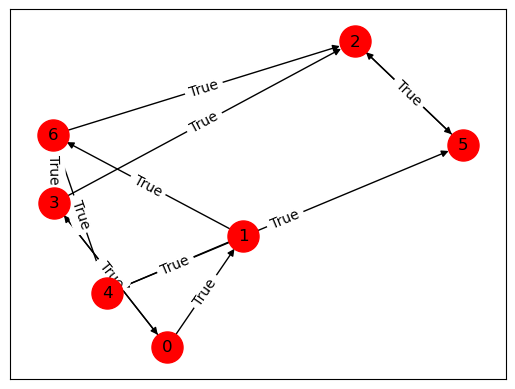

In [7]:
gb.viz.draw(example_matrix)

## MSBFS-Parents

In [9]:
def msbfs_parents(
    matrix: Matrix,
    starting_vertices: list,
    *,
    semiring=semiring.min_first,
):
    # Всего вершин
    N = matrix.nrows

    # Создаем wavefront матрицу
    wavefront_data = [
        [],
        [],
        [],
    ]

    # Создаем parents матрицу
    parents_data = [
        [],
        [],
        [],
    ]

    for idx, el in enumerate(starting_vertices):
        # Добавляем значения чтобы потом создать wavefront матрицу
        wavefront_data[0].append(idx)
        wavefront_data[1].append(el)
        wavefront_data[2].append(el)

        # Добавляем значения чтобы потом создать parents матрицу
        parents_data[0].append(idx)
        parents_data[1].append(el)
        parents_data[2].append(-1)  # parent для стартовой вершины равен -1

    # Создаем матрицы wavefront и parents
    wavefront_matrix = Matrix.from_coo(wavefront_data[0], wavefront_data[1], wavefront_data[2], ncols=N, dtype="INT64")
    parents_matrix = Matrix.from_coo(parents_data[0], parents_data[1], parents_data[2], ncols=N, dtype="INT64")

    # Создаем index_ramp
    index_ramp = Vector(dtypes.UINT64, N)
    index_ramp.build(range(N), range(N))

    # Начинаем цикл
    while wavefront_matrix.nvals > 0:
        # Записываем именно индексы текущих вершин
        wavefront_matrix << wavefront_matrix.ewise_mult(index_ramp, binary.second)

        # print(wavefront_matrix)
        # print(parents_matrix)

        # Ищем родителей 
        wavefront_matrix(~parents_matrix.S, replace=True) << wavefront_matrix.mxm(matrix, semiring)

        # Записываем родителей
        parents_matrix(binary.plus) << wavefront_matrix

    # Записываем недостижимых как -2
    parents_matrix(~parents_matrix.S) << -2

    # массив пар: стартовая вершина, и массив (parents)
    start_vertices_parents_pairs = []
    
    parent_matrix_arr = parents_matrix.to_dense()

    for idx, el in enumerate(starting_vertices):
        cur_parents = parent_matrix_arr[idx].tolist()
        start_vertices_parents_pairs.append((el, cur_parents))
        
    return start_vertices_parents_pairs

In [10]:
# example_wf_matrix = msbfs_parents(example_matrix, [1, 2])
# example_wf_matrix

## MSBFS-Levels

In [12]:
def msbfs_levels(
    matrix: Matrix,
    starting_vertices: list,
    *,
    semiring=semiring.lor_land,
):
    # Всего вершин
    N = matrix.nrows

    # Создаем f матрицу
    f_data = [
        [],
        [],
        [],
    ]

    for idx, el in enumerate(starting_vertices):
        # Добавляем значения чтобы потом создать wavefront матрицу
        f_data[0].append(idx)
        f_data[1].append(el)
        f_data[2].append(True)

    # Создаем f-матрицу
    f_matrix = Matrix.from_coo(f_data[0], f_data[1], f_data[2], ncols=N, dtype="bool")

    # Создаем result таблицу
    result_matrix = Matrix(dtypes.INT64, nrows=len(starting_vertices), ncols=N)

    # Флаг для выхода из цикла
    succ = Scalar(bool)

    # Уровень
    level = -1
    while True:
        level += 1

        # Записываем level в матрицу
        result_matrix(mask=f_matrix.V) << level

        # 
        f_matrix(~result_matrix.S, replace=True) << f_matrix.mxm(matrix, semiring)

        succ << f_matrix.reduce_rowwise(monoid.lor).reduce(monoid.lor)

        # Не можем дальше продолжать
        if not succ:
            break

    # Заполняем недостижимые -1
    result_matrix(~result_matrix.S) << -1
    
    # массив пар: стартовая вершина, и массив (levels)
    start_vertices_levels_pairs = []
    
    level_matrix_arr = result_matrix.to_dense()

    for idx, el in enumerate(starting_vertices):
        cur_levels = level_matrix_arr[idx].tolist()
        start_vertices_levels_pairs.append((el, cur_levels))
        
    return start_vertices_levels_pairs

In [13]:
# example_f_matrix = msbfs_levels(example_matrix, [1, 2])
# example_f_matrix

## Тесты

### Тестируем работу msbfs_parents

In [16]:
def test_msbfs_parents(semiring_operation=semiring.min_first):
    edges = [
        [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
        [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
    ]

    example_matrix = load_graph_from_coo(edges)

    linear_matrix = Matrix.from_coo([0,1,2,3], [1,2,3,4], [True]*4, nrows=5, ncols=5)
    cycle_matrix = Matrix.from_coo([0,1,2,3], [1,2,3,0], [True]*4, nrows=4, ncols=4)
    star_matrix = Matrix.from_coo([0,0,0,0], [1,2,3,4], [True]*4, nrows=5, ncols=5)
    
    # Пары для теста
    test_pairs = {
        # Граф из семинара
        (example_matrix, (1, 2)): [
            [3, -1, 6, 6, 1, 4, 1],
            [-2, -2, -1, -2, -2, 2, -2],
        ],
        (example_matrix, (0,)): [
            [-1, 0, 3, 0, 1, 2, 1],
        ],
        (example_matrix, (6,)): [
            [3, 0, 6, 6, 6, 2, -1],
        ],
        (example_matrix, (0, 3, 5)): [
            [-1, 0, 3, 0, 1, 2, 1],
            [3, 0, 3, -1, 1, 2, 1],
            [-2, -2, 5, -2, -2, -1, -2],
        ],
        # Граф типа 0 -> 1 -> 2 -> 3 -> 4
        (linear_matrix, (0,)): [
            [-1, 0, 1, 2, 3],
        ],
        (linear_matrix, (2,)): [
            [-2, -2, -1, 2, 3],
        ],
        (linear_matrix, (0, 4)): [
            [-1, 0, 1, 2, 3],
            [-2, -2, -2, -2, -1],
        ],
        # Граф с циклом 0 -> 1 -> 2 -> 3 -> 0 
        (cycle_matrix, (0,)): [
            [-1, 0, 1, 2],
        ],
        (cycle_matrix, (2,)): [
            [3, 0, -1, 2],
        ],
        (cycle_matrix, (0, 2)): [
            [-1, 0, 1, 2],
            [3, 0, -1, 2],
        ],
         # Граф типа 0 -> {1,2,3,4} 
        (star_matrix, (0,)): [
            [-1, 0, 0, 0, 0],
        ],
        (star_matrix, (1,)): [
            [-2, -1, -2, -2, -2],
        ],
    }

    # Идем по всем тест кейсам 
    # Массивы parent'ов должны совпадать для каждой стартовой вершины
    for key, value in test_pairs.items():
        # Прогоняем наш msbfs алгоритм для поиска родителей
        ans_pairs = msbfs_parents(*key, semiring=semiring_operation)

        # Записываем по порядку массивы родителей для каждой стартовой вершины
        ans_lists = []

        for pair in ans_pairs:
            ans_lists.append(pair[1])

        # print(ans_lists)
        # print(value)
        assert ans_lists == value, "Где то ошибка!"

    print("Все тесты пройдены!")

test_msbfs_parents()

Все тесты пройдены!


### Тестируем работу msbfs_levels

In [18]:
def test_msbfs_levels(semiring_operation=semiring.lor_land):
    edges = [
        [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
        [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
    ]

    example_matrix = load_graph_from_coo(edges)

    linear_matrix = Matrix.from_coo([0,1,2,3], [1,2,3,4], [True]*4, nrows=5, ncols=5)
    cycle_matrix = Matrix.from_coo([0,1,2,3], [1,2,3,0], [True]*4, nrows=4, ncols=4)
    star_matrix = Matrix.from_coo([0,0,0,0], [1,2,3,4], [True]*4, nrows=5, ncols=5)
    
    # Пары для теста
    test_pairs = {
        # Граф из семинара
        (example_matrix, (1, 2)): [
            [3, 0, 2, 2, 1, 2, 1],
            [-1, -1, 0, -1, -1, 1, -1],
        ],
        (example_matrix, (0,)): [
            [0, 1, 2, 1, 2, 3, 2],
        ],
        (example_matrix, (6,)): [
            [2, 3, 1, 1, 1, 2, 0],
        ],
        (example_matrix, (0, 3, 5)): [
            [0, 1, 2, 1, 2, 3, 2],
            [1, 2, 1, 0, 3, 2, 3],
            [-1, -1, 1, -1, -1, 0, -1],
        ],
        # Граф типа 0 -> 1 -> 2 -> 3 -> 4
        (linear_matrix, (0,)): [
            [0, 1, 2, 3, 4],
        ],
        (linear_matrix, (2,)): [
            [-1, -1, 0, 1, 2],
        ],
        (linear_matrix, (0, 4)): [
            [0, 1, 2, 3, 4],
            [-1, -1, -1, -1, 0],
        ],
        # Граф с циклом 0 -> 1 -> 2 -> 3 -> 0
        (cycle_matrix, (0,)): [
            [0, 1, 2, 3],
        ],
        (cycle_matrix, (2,)): [
            [2, 3, 0, 1],
        ],
        (cycle_matrix, (0, 2)): [
            [0, 1, 2, 3],
            [2, 3, 0, 1],
        ],
        # Граф типа 0 -> {1,2,3,4}
        (star_matrix, (0,)): [
            [0, 1, 1, 1, 1],
        ],
        (star_matrix, (1,)): [
            [-1, 0, -1, -1, -1],
        ],
    }

    # Идем по всем тест кейсам 
    # Массивы levels'ов должны совпадать для каждой стартовой вершины
    for key, value in test_pairs.items():
        # Прогоняем наш msbfs алгоритм для поиска levels
        ans_pairs = msbfs_levels(*key, semiring=semiring_operation)

        # Записываем по порядку массивы levels для каждой стартовой вершины
        ans_lists = []

        for pair in ans_pairs:
            ans_lists.append(pair[1])

        # print(ans_lists)
        # print(value)
        assert ans_lists == value, "Где то ошибка!"

    print("Все тесты пройдены!")

test_msbfs_levels()

Все тесты пройдены!


## Работа с графами с сайта SuiteSparse Matrix Collection

Получаем имена файлов .mtx

In [21]:
# Пути до папок с файлами с графами (расширение .mtx)
files_with_graphs = []

for file in Path("./graphs_task_3_data").iterdir():
    if file.is_file():
        if file.suffix == ".mtx":
            files_with_graphs.append(file)

Преобразуем все графы в объекты матриц из python-graphblas

In [23]:
matrices_graphs = []

for filepath in files_with_graphs:
    current_sparse_matrix = mmread(filepath)
    current_A = from_scipy_sparse(csr_matrix(current_sparse_matrix))

    matrices_graphs.append(current_A)

Оцениваем время работы наших алгоритмов msbfs_parents, mbfs_levels.

In [25]:
# Наши алгоритмы
algorithms = {
    "msbfs_parents": msbfs_parents,
    "msbfs_levels": msbfs_levels
}

starting_vertices_grid = [
    np.arange(0, i).tolist() for i in [5, 10, 10 ** 2, 10 ** 3]
]

# Для сохранения результатов
results_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in algorithms.keys()}

# Также будем хранить информацию о конкретном графе и кол-ве стартовых вершин в msbfs 
results_dct["Кол-во строк в матрице смежности"] = []
results_dct["Кол-во колонок в матрице смежности"] = []
results_dct["Непустых значений (не 0)"] = []
results_dct["Кол-во стартовых вершин"] = []
results_dct["Разреженность"] = []

for current_matrix in matrices_graphs:
    for starting_vertices in starting_vertices_grid:
        # Записываем информацию он конкретном графе
        results_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
        results_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
        results_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
        results_dct["Кол-во стартовых вершин"].append(len(starting_vertices))
        results_dct["Разреженность"].append(1 - (current_matrix.nvals) / (current_matrix.nrows * current_matrix.ncols))

        # Идем по алгоритмам
        for algorithm_name, algorithm_function in algorithms.items():
            # Засекаем время в начале
            start_time = time.perf_counter()

            # Прогоняем наш алгоритм на графе
            _ = algorithm_function(current_matrix, starting_vertices)

            # Считаем время в конце
            end_time = time.perf_counter()
    
            total_time = end_time - start_time
    
            results_dct[f"Time in sec: {algorithm_name}"].append(total_time)

## Анализ результатов на графах с сайта SuiteSparse Matrix Collection

In [27]:
# Смотрим на результаты прогона наших алгоритмов по графам
results_df = pd.DataFrame(results_dct)
results_df.head(2)

,Time in sec: msbfs_parents,Time in sec: msbfs_levels,Кол-во строк в матрице смежности,Кол-во колонок в матрице смежности,Непустых значений (не 0),Кол-во стартовых вершин,Разреженность
0,0.030371,0.059069,59310,59310,837936,5,0.999762
1,0.043593,0.071386,59310,59310,837936,10,0.999762


Проанализируем зависимость времени алгоритмов от кол-ва вершин (то есть размера графа) и от кол-ва стартовых вершин в msbfs алгоритмах.

In [29]:
def plot_results_suitesparse(df):
    # Время от числа вершин
    grouped = df.groupby("Кол-во строк в матрице смежности").mean()

    plt.figure(figsize=(10, 5))
    plt.plot(grouped.index, grouped["Time in sec: msbfs_parents"], marker="o", label="msbfs_parents")
    plt.plot(grouped.index, grouped["Time in sec: msbfs_levels"], marker="s", label="msbfs_levels")
    plt.xlabel("Число вершин")
    plt.ylabel("Время в сек")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Зависимость времени от размера графа (SuiteSparse)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Время от кол-ва стартовых вершин
    grouped_starts = df.groupby("Кол-во стартовых вершин").mean()

    plt.figure(figsize=(10, 5))
    plt.plot(grouped_starts.index, grouped_starts["Time in sec: msbfs_parents"], marker="o", label="msbfs_parents")
    plt.plot(grouped_starts.index, grouped_starts["Time in sec: msbfs_levels"], marker="s", label="msbfs_levels")
    plt.xlabel("Кол-во стартовых вершин")
    plt.ylabel("Время в сек")
    plt.title("Зависимость времени от кол-ва стартовых вершин (SuiteSparse)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

У большинства графиков в SuiteSparse высокая разреженность, лучше построим график зависимости от размера графа (от числа вершин) и от кол-ва стартовых вершин. 

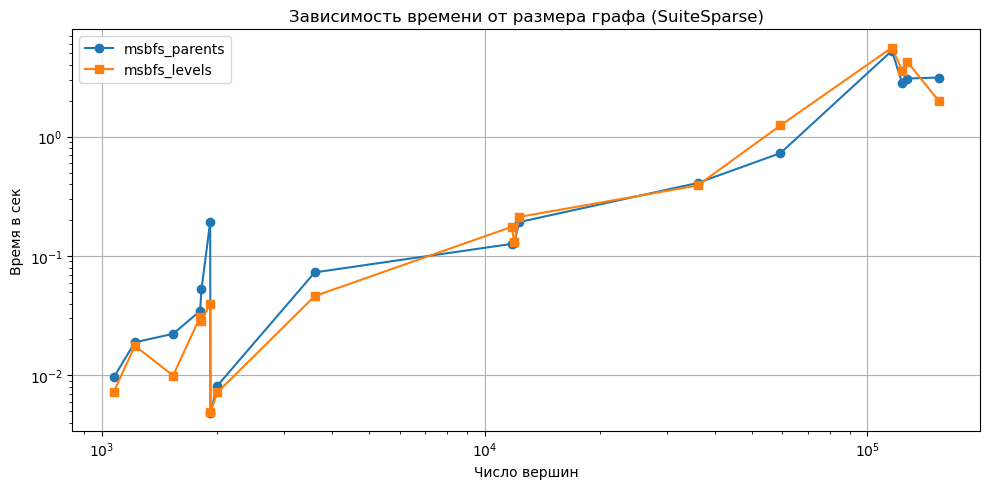

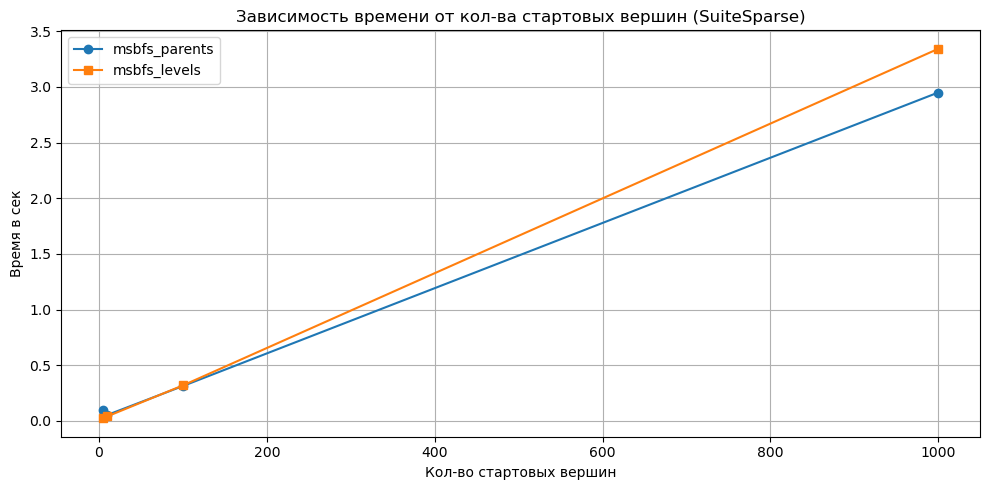

In [31]:
plot_results_suitesparse(results_df)

- При росте количества стартовых вершин оба алгоритма замедляются линейно, однако msbfs_levels работает медленнее, чем msbfs_parents. При этом разрыв между ними увеличивается с ростом числа стартовых вершин.

- При росте размер графа (кол-ва вершин) время на исполнение обоих алгоритмов растет. Для небольшого числа вершин их увеличение необязательно приводит к увеличению времени работы алгоритмов. 

## Работа со случайно инициализированными графами.

In [34]:
def generate_graph_randomly(
    n_vertices: int,
    p_of_edge: float,
    random_seed: int = 42
) -> Matrix:
    # Задаем генератор случайных чисел
    rng = np.random.default_rng(random_seed)

    # Выбираем индексы
    row_idx, col_idx = np.indices((n_vertices, n_vertices))

    row_idx = row_idx.flatten()
    col_idx = col_idx.flatten()

    # Создаем маску
    mask = (rng.random(len(row_idx)) <= p_of_edge) & (row_idx != col_idx)

    # Оставляем только те пары вершин, которые прошли маску
    src = row_idx[mask]
    dst = col_idx[mask]

    # Непустые значения = 1
    vals = np.ones(len(src), dtype=int)
    
    return Matrix.from_coo(src, dst, vals, nrows=n_vertices, ncols=n_vertices)

Запустим экперименты для анализа времени работы msbfs алгоритмов в разных конфигурациях заданных вершин, разреженности, и кол-ва стартовых вершин.

In [36]:
# Сетка значений кол-ва стартовых вершин
starting_vertices_grid = [
    np.arange(0, i).tolist() for i in [5, 10, 10 ** 2, 10 ** 3]
]

# Для сохранения результатов
results_random_graphs_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in algorithms.keys()}

# Также будем хранить информацию о конкретном графе и кол-ве стартовых вершин в msbfs 
results_random_graphs_dct["Кол-во строк в матрице смежности"] = []
results_random_graphs_dct["Кол-во колонок в матрице смежности"] = []
results_random_graphs_dct["Непустых значений (не 0)"] = []
results_random_graphs_dct["Кол-во стартовых вершин"] = []
results_random_graphs_dct["Разреженность"] = []

# Кол-во экспериментов
n_runs = 25

# Задаем изначальный seed
current_seed = 1

# Сетка для значений кол-ва вершин
n_vertices_grid = [10 ** i for i in range(1, 5)]

# Сетка для значений показателя разреженности
p_of_edge_grid = [0.001, 0.005, 0.01, 0.05] # was also 0.1

for current_n_vertices in n_vertices_grid:
    for current_start_vertices in starting_vertices_grid:
        # Стартовых вершин не может быть больше, чем вершин конкретного графа
        if max(current_start_vertices) >= current_n_vertices:
            continue
        for current_p_edge in p_of_edge_grid:
            for run in range(1, n_runs + 1):
                current_matrix = generate_graph_randomly(current_n_vertices, current_p_edge, random_seed=current_seed)
                results_random_graphs_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
                results_random_graphs_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
                results_random_graphs_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
                results_random_graphs_dct["Кол-во стартовых вершин"].append(len(current_start_vertices))
                # results_random_graphs_dct["Разреженность"].append(1 - (current_matrix.nvals) / (current_matrix.nrows * current_matrix.ncols))
                results_random_graphs_dct["Разреженность"].append(1 - current_p_edge)

                # Идем по алгоритмам
                for algorithm_name, algorithm_function in algorithms.items():
                    # Засекаем время в начале
                    start_time = time.perf_counter()
        
                    # Прогоняем наш алгоритм на графе
                    _ = algorithm_function(current_matrix, current_start_vertices)
        
                    # Считаем время в конце
                    end_time = time.perf_counter()
            
                    total_time = end_time - start_time
            
                    results_random_graphs_dct[f"Time in sec: {algorithm_name}"].append(total_time)

                # Обновляем seed
                current_seed += 1

## Анализ результатов на случайных графах с сайта (с разным кол-вом вершин, степенью разреженности, кол-вом стартовых вершин)

In [38]:
# Формируем DataFrame
random_graphs_results_df = pd.DataFrame(results_random_graphs_dct)
random_graphs_results_df.head(10)

,Time in sec: msbfs_parents,Time in sec: msbfs_levels,Кол-во строк в матрице смежности,Кол-во колонок в матрице смежности,Непустых значений (не 0),Кол-во стартовых вершин,Разреженность
0,0.003839,0.000508,10,10,0,5,0.999
1,0.000204,0.000108,10,10,0,5,0.999
2,0.000133,0.000091,10,10,0,5,0.999
3,0.000122,0.000090,10,10,0,5,0.999
4,0.000137,0.000086,10,10,0,5,0.999
5,0.000117,0.000081,10,10,0,5,0.999
6,0.000110,0.000082,10,10,0,5,0.999
7,0.000115,0.000081,10,10,0,5,0.999
8,0.000117,0.000083,10,10,0,5,0.999
9,0.000115,0.000081,10,10,0,5,0.999


In [39]:
def plot_time_vs_param(df, group_cols, x_level, subplot_level, algos_cols, xlabel, title_prefix):
    # Группируем по колонкам группировки
    grouped = df.groupby(group_cols)[algos_cols].mean()

    # Level для subplots: или p_edge или n_vertices
    subplot_values = grouped.index.get_level_values(subplot_level).unique()

    n_plots = len(subplot_values)
    n_cols = 3

    # Целочисленным делением с округлением вверх считаем кол-во нужных строк для графика
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=False)

    # Для удобного прохода по циклу
    axes = axes.flatten()
    
    for i, val in enumerate(subplot_values):
        ax = axes[i]
        subset = grouped[grouped.index.get_level_values(subplot_level) == val]
        for col in algos_cols:
            ax.plot(subset.index.get_level_values(x_level), subset[col], marker='o', label=col.replace("Time in sec: ", ""))
        ax.set_title(f"{title_prefix} = {val}")
        ax.set_xlabel(xlabel)
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.grid(True)

    # Убираем те оси/участки графика, которые нам уже не нужны
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)
    
    fig.supylabel("Время (в сек)")

    # Легенда
    axes[n_plots - 1].legend(bbox_to_anchor=(1.05, 1)) 
    plt.tight_layout()

Посмотрим на зависимость времени работы алгоритмов от числа вершин (в разбивке по разному уровню разреженности).

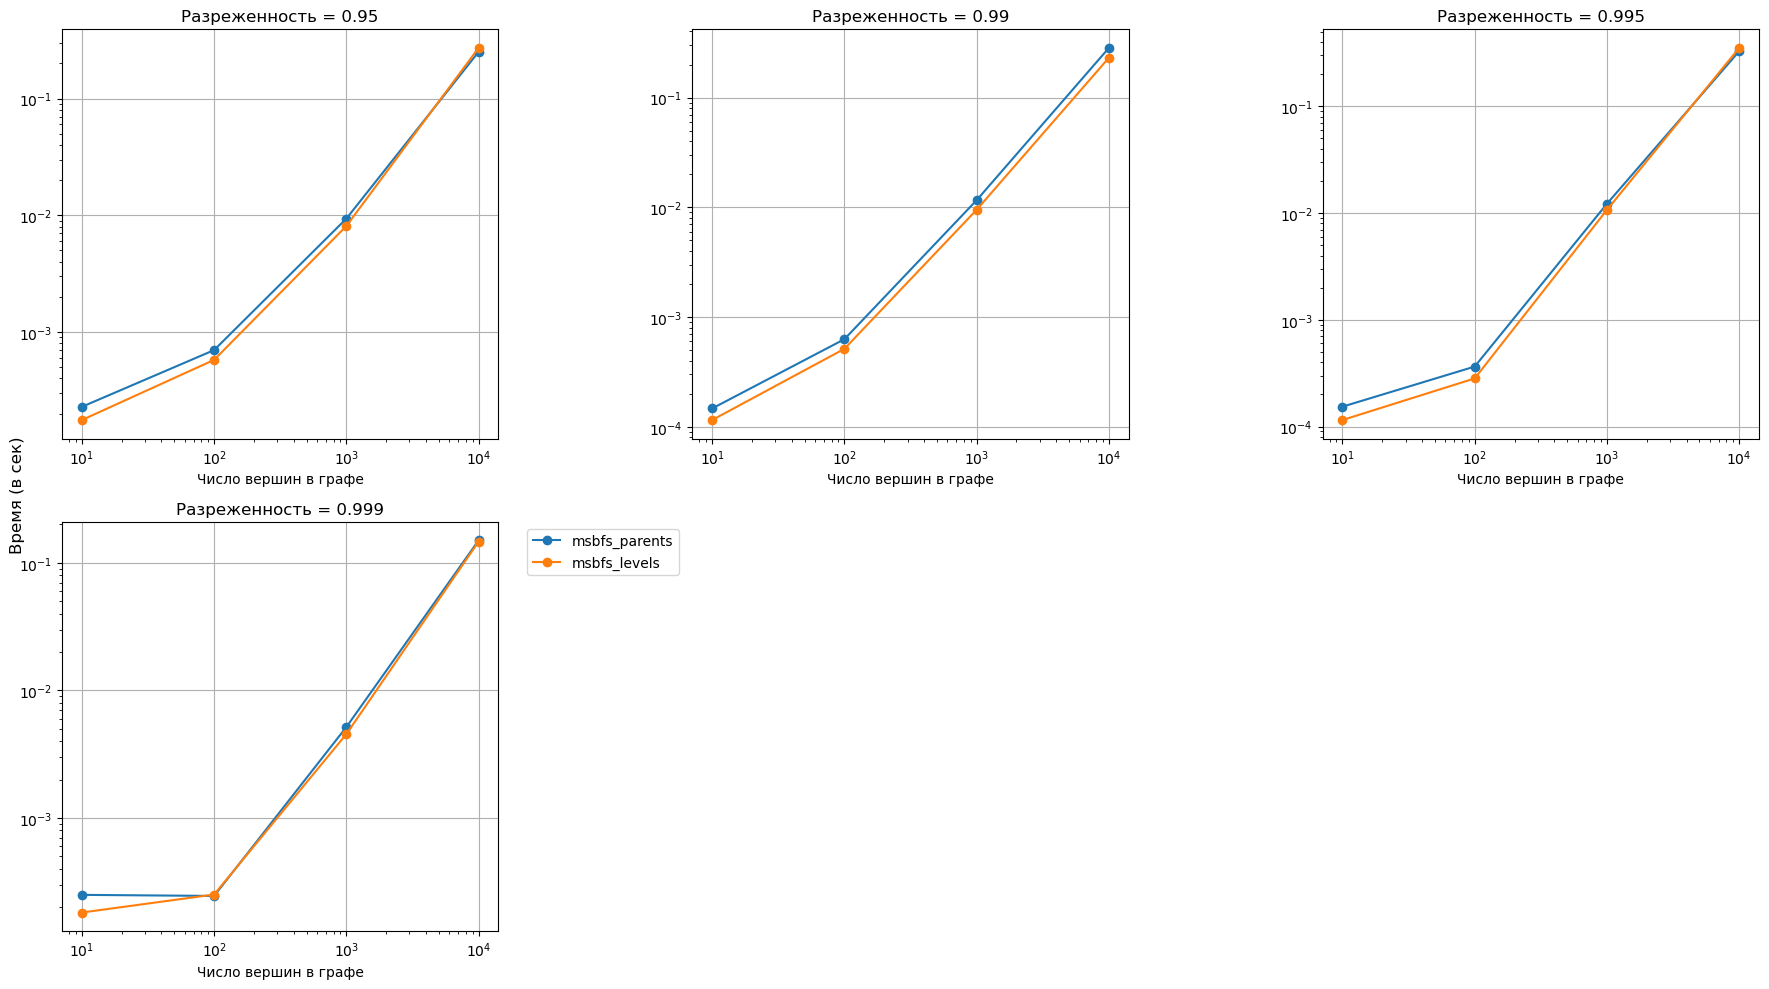

In [41]:
algos_cols = [f"Time in sec: {name}" for name in algorithms.keys()]

plot_time_vs_param(
    df=random_graphs_results_df,
    group_cols=["Кол-во строк в матрице смежности", "Разреженность"],
    x_level="Кол-во строк в матрице смежности",
    subplot_level="Разреженность",
    algos_cols=algos_cols,
    xlabel="Число вершин в графе",
    title_prefix="Разреженность"
)

- При росте числа вершин время работы алгоритмов msbfs_levels и msbfs_parents увеличивается.

Посмотрим на зависимость времени работы алгоритмов от кол-ва стартовых вершин (в разбивке по размеру графа).

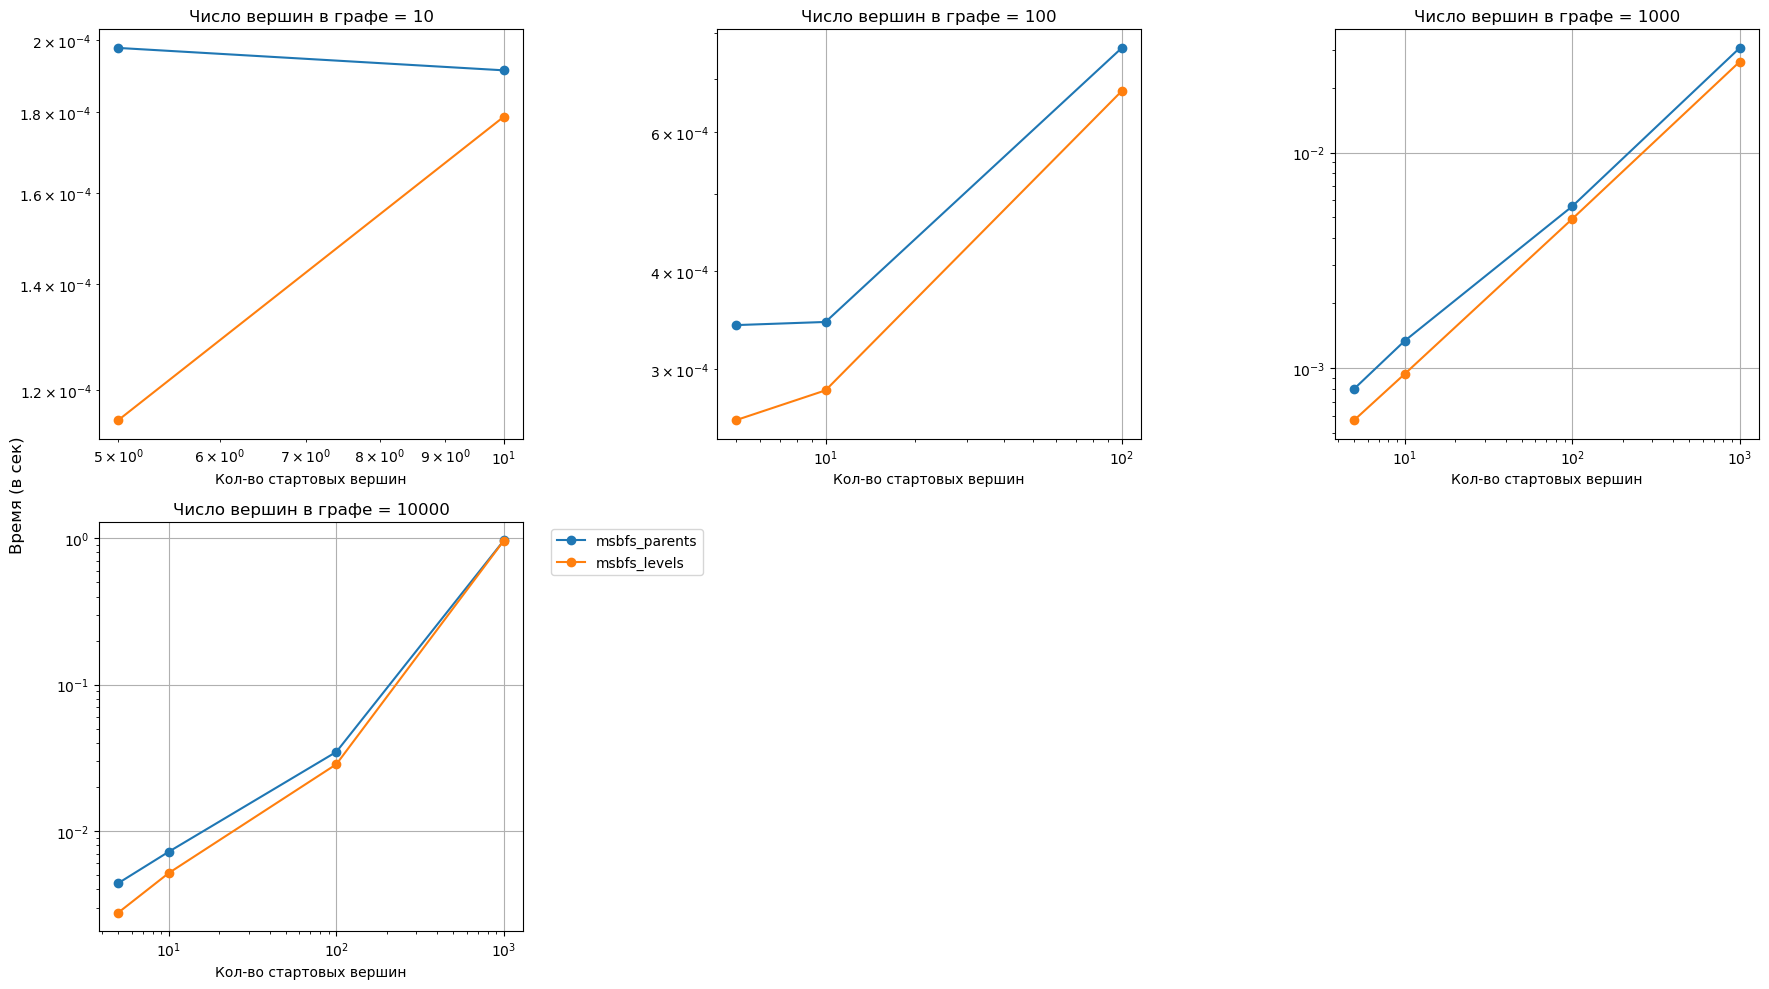

In [44]:
# График 2: X = число вершин, subplot по кол-ву стартовых вершин
plot_time_vs_param(
    df=random_graphs_results_df,
    group_cols=["Кол-во строк в матрице смежности", "Кол-во стартовых вершин"],
    x_level="Кол-во стартовых вершин",
    subplot_level="Кол-во строк в матрице смежности",
    algos_cols=algos_cols,
    xlabel="Кол-во стартовых вершин",
    title_prefix="Число вершин в графе"
)

- Для больших графов при увеличении кол-ва стартовых вершин также увеличивается и время работы алгоритмов (при этом эта зависимость похожа на линейную)

- Для очень маленьких графов (10–100 вершин) зависимость не наблюдается: при увеличении кол-ва стартовых вершин время исполнения алгоритмов может даже упасть.

Посмотрим на зависимость времени работы алгоритмов от уровня разреженнности (в разбивке по размеру графа).

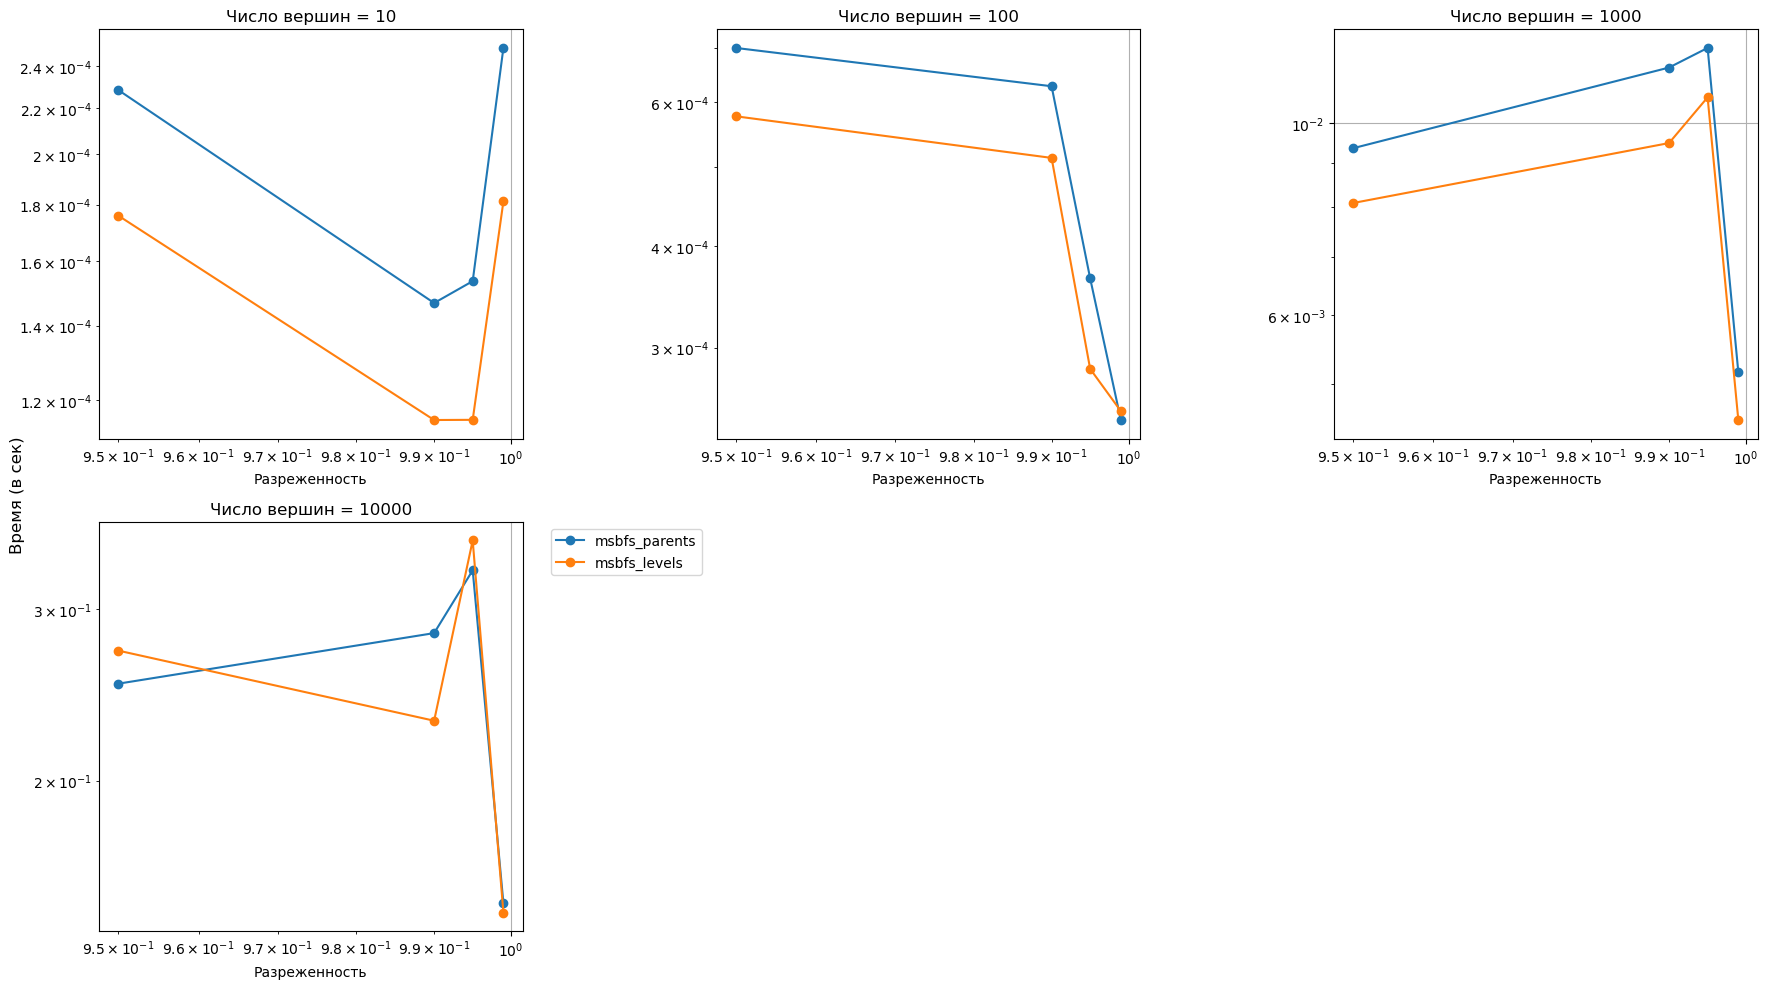

In [47]:
# График 3: X = разреженность, subplot по размеру графа
plot_time_vs_param(
    df=random_graphs_results_df,
    group_cols=["Разреженность", "Кол-во строк в матрице смежности"],
    x_level="Разреженность",
    subplot_level="Кол-во строк в матрице смежности",
    algos_cols=algos_cols,
    xlabel="Разреженность",
    title_prefix="Число вершин"
)

- Для больших графов при увеличении разреженности время работы алгоритмов снижается.

- Для маленьких графов (10 вершин) зависимость от разреженности выражена слабо и может быть даже обратной: время работы алгоритмов может вырасти при увеличении разреженности.

## Сравнение полуколец: min_first/lor_land vs any_first/any_pair

Протестируем msbfs_parents и msbfs_levels, так же как тестировали до этого, только теперь будем использовать другие операции:
any_first и any_pair, соответственно.

Протестируем msbfs_parents с any_first.

In [73]:
test_msbfs_parents(semiring.any_first)

AssertionError: Где то ошибка!

Ожидаемо выпадает ошибка, так как результат недетерминирован, как при использовании semiring.min_first: а тесты рассчитаны именно на минимальных по индексу родителей.

Протестируем msbfs_levels с any_pair.

In [77]:
test_msbfs_levels(semiring.any_pair)

Все тесты пройдены!


Для levels у нас получился всегда одинаковый результат вне зависимости от полукольца, потому что записывается только номер уровня, а не номер конкретной вершины родителя.

Посмотрим на зависимость времени работы алгоритмов от полукольца.

In [81]:
# Для сохранения результатов
results_comparison_dct = {}

# Ключи по которым будем сохранять результаты алгоритмов с разными полукольцами
semirings_dct = {
    "parents semiring=min_first": semiring.min_first,
    "parents semiring=any_first": semiring.any_first,
    "levels semiring=lor_land": semiring.lor_land,
    "levels semiring=any_pair": semiring.any_pair,
}

for k in semirings_dct.keys():
    results_comparison_dct[k] = []

# Также будем хранить информацию о конкретном графе и кол-ве стартовых вершин в msbfs 
results_comparison_dct["Кол-во строк в матрице смежности"] = []
results_comparison_dct["Кол-во колонок в матрице смежности"] = []
results_comparison_dct["Непустых значений (не 0)"] = []
results_comparison_dct["Кол-во стартовых вершин"] = []
results_comparison_dct["Разреженность"] = []

# Задаем изначальный seed
current_seed = 1

# Используем те же сетки, что и в предыдущих заданиях
for current_n_vertices in n_vertices_grid:
    for current_start_vertices in starting_vertices_grid:
        # Стартовых вершин не может быть больше, чем вершин конкретного графа
        if max(current_start_vertices) >= current_n_vertices:
            continue
        for current_p_edge in p_of_edge_grid:
            for run in range(1, n_runs + 1):
                current_matrix = generate_graph_randomly(current_n_vertices, current_p_edge, random_seed=current_seed)
                results_comparison_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
                results_comparison_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
                results_comparison_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
                results_comparison_dct["Кол-во стартовых вершин"].append(len(current_start_vertices))
                results_comparison_dct["Разреженность"].append(1 - current_p_edge)

                for semiring_name, current_semiring in semirings_dct.items():
                    # Засекаем время в начале
                    start_time = time.perf_counter()
                    
                    if semiring_name.startswith("parents"):
                        _ = msbfs_parents(current_matrix, current_start_vertices, semiring=current_semiring)
                    else:
                        _ = msbfs_levels(current_matrix, current_start_vertices, semiring=current_semiring)
        
                    # Считаем время в конце
                    end_time = time.perf_counter()
            
                    total_time = end_time - start_time
            
                    # Добавляем время
                    results_comparison_dct[semiring_name].append(total_time)

                # Обновляем seed
                current_seed += 1

### Сравним алгоритмы

In [84]:
results_comparison_df = pd.DataFrame(results_comparison_dct)
results_comparison_df.head(10)

,parents semiring=min_first,parents semiring=any_first,levels semiring=lor_land,levels semiring=any_pair,Кол-во строк в матрице смежности,Кол-во колонок в матрице смежности,Непустых значений (не 0),Кол-во стартовых вершин,Разреженность
0,0.026917,0.000444,0.000148,0.000110,10,10,0,5,0.999
1,0.000210,0.000228,0.000173,0.000167,10,10,0,5,0.999
2,0.000231,0.000219,0.000164,0.000163,10,10,0,5,0.999
3,0.000227,0.000184,0.000098,0.000096,10,10,0,5,0.999
4,0.000131,0.000127,0.000104,0.000135,10,10,0,5,0.999
5,0.000215,0.000209,0.000159,0.000154,10,10,0,5,0.999
6,0.000214,0.000209,0.000162,0.000153,10,10,0,5,0.999
7,0.000217,0.000206,0.000159,0.000123,10,10,0,5,0.999
8,0.000133,0.000129,0.000098,0.000096,10,10,0,5,0.999
9,0.000132,0.000130,0.000097,0.000096,10,10,0,5,0.999


Теперь посмотрим на время работы msbfs_parents алгоритма в зависимости от полукольца: semiring.min_first или semiring.any_first.
Разбивка по уровню разреженности, по оси x - число вершин в графе.

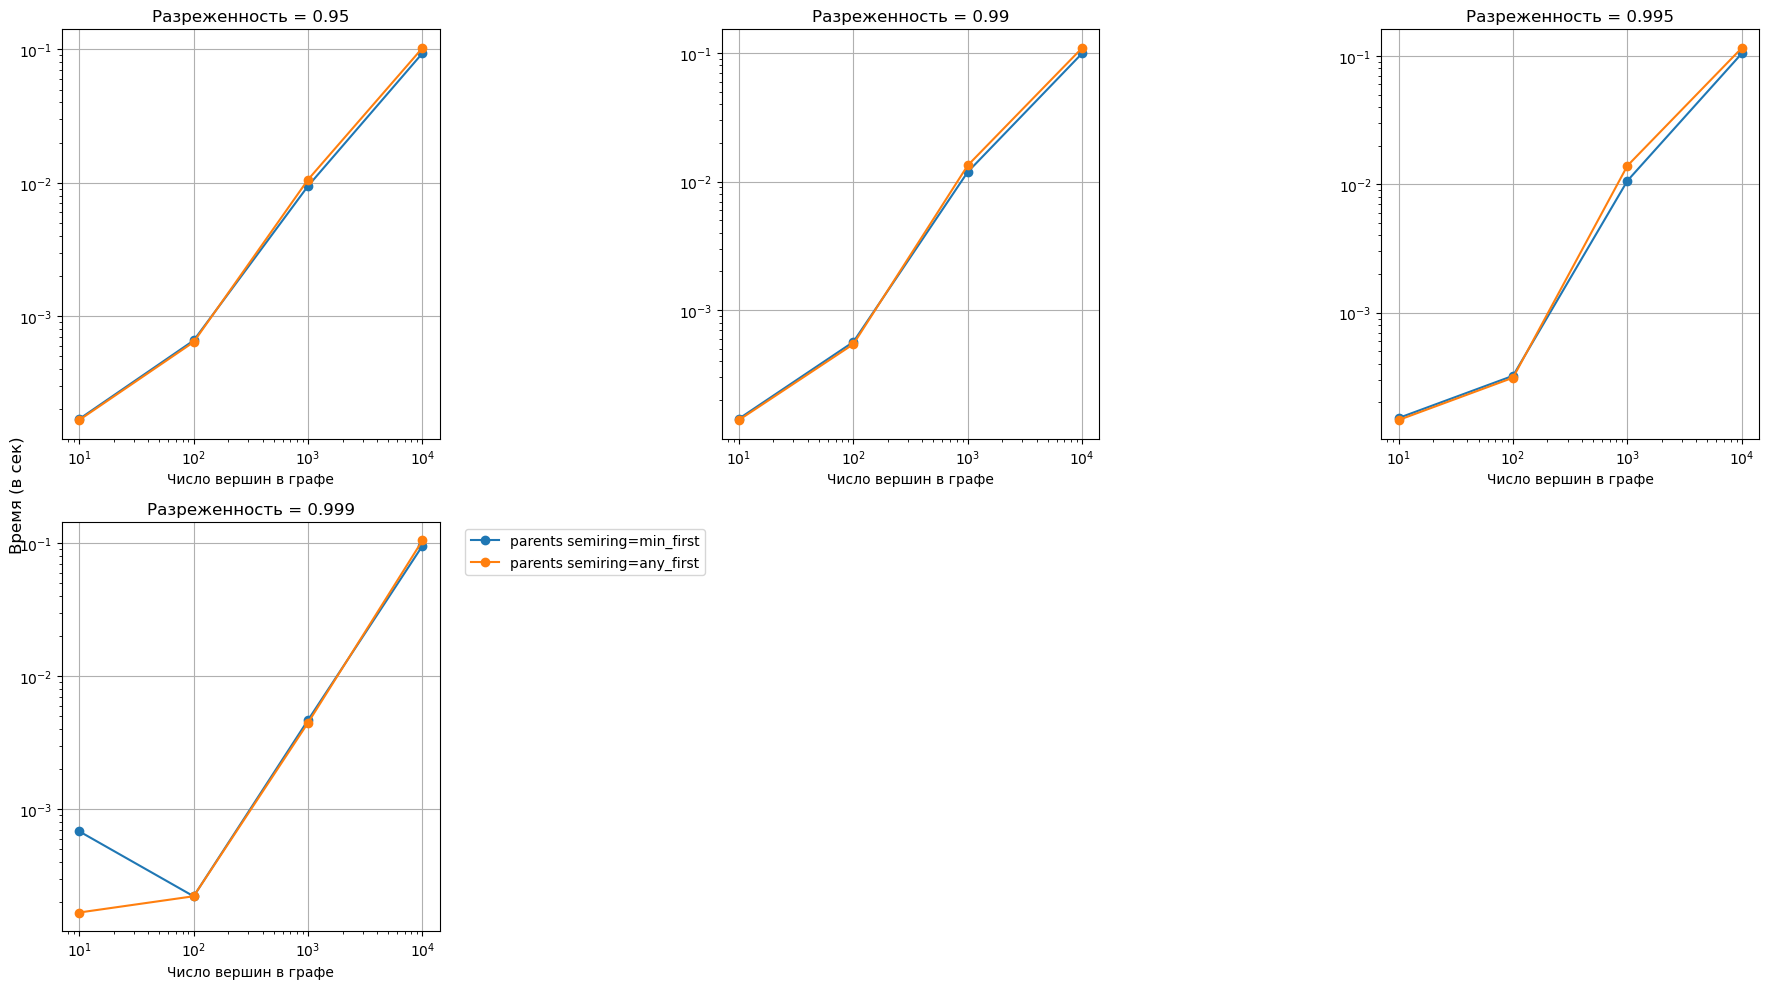

In [86]:
plot_time_vs_param(
    df=results_comparison_df,
    group_cols=["Кол-во строк в матрице смежности", "Разреженность"],
    x_level="Кол-во строк в матрице смежности",
    subplot_level="Разреженность",
    algos_cols=["parents semiring=min_first", "parents semiring=any_first"],
    xlabel="Число вершин в графе",
    title_prefix="Разреженность"
)

Полукольца min_first и any_first для алгоритма msbfs_parents показывают практически одинаковое время работы при всех размерах графов и уровнях разреженности — замена полукольца с min_first на any_first не дает заметного выигрыша в скорости работы алгоритма.

Теперь посмотрим на время работы msbfs_levels алгоритма в зависимости от полукольца: semiring.lor_land или semiring.any_pair.
Разбивка по уровню разреженности, по оси x - число вершин в графе.

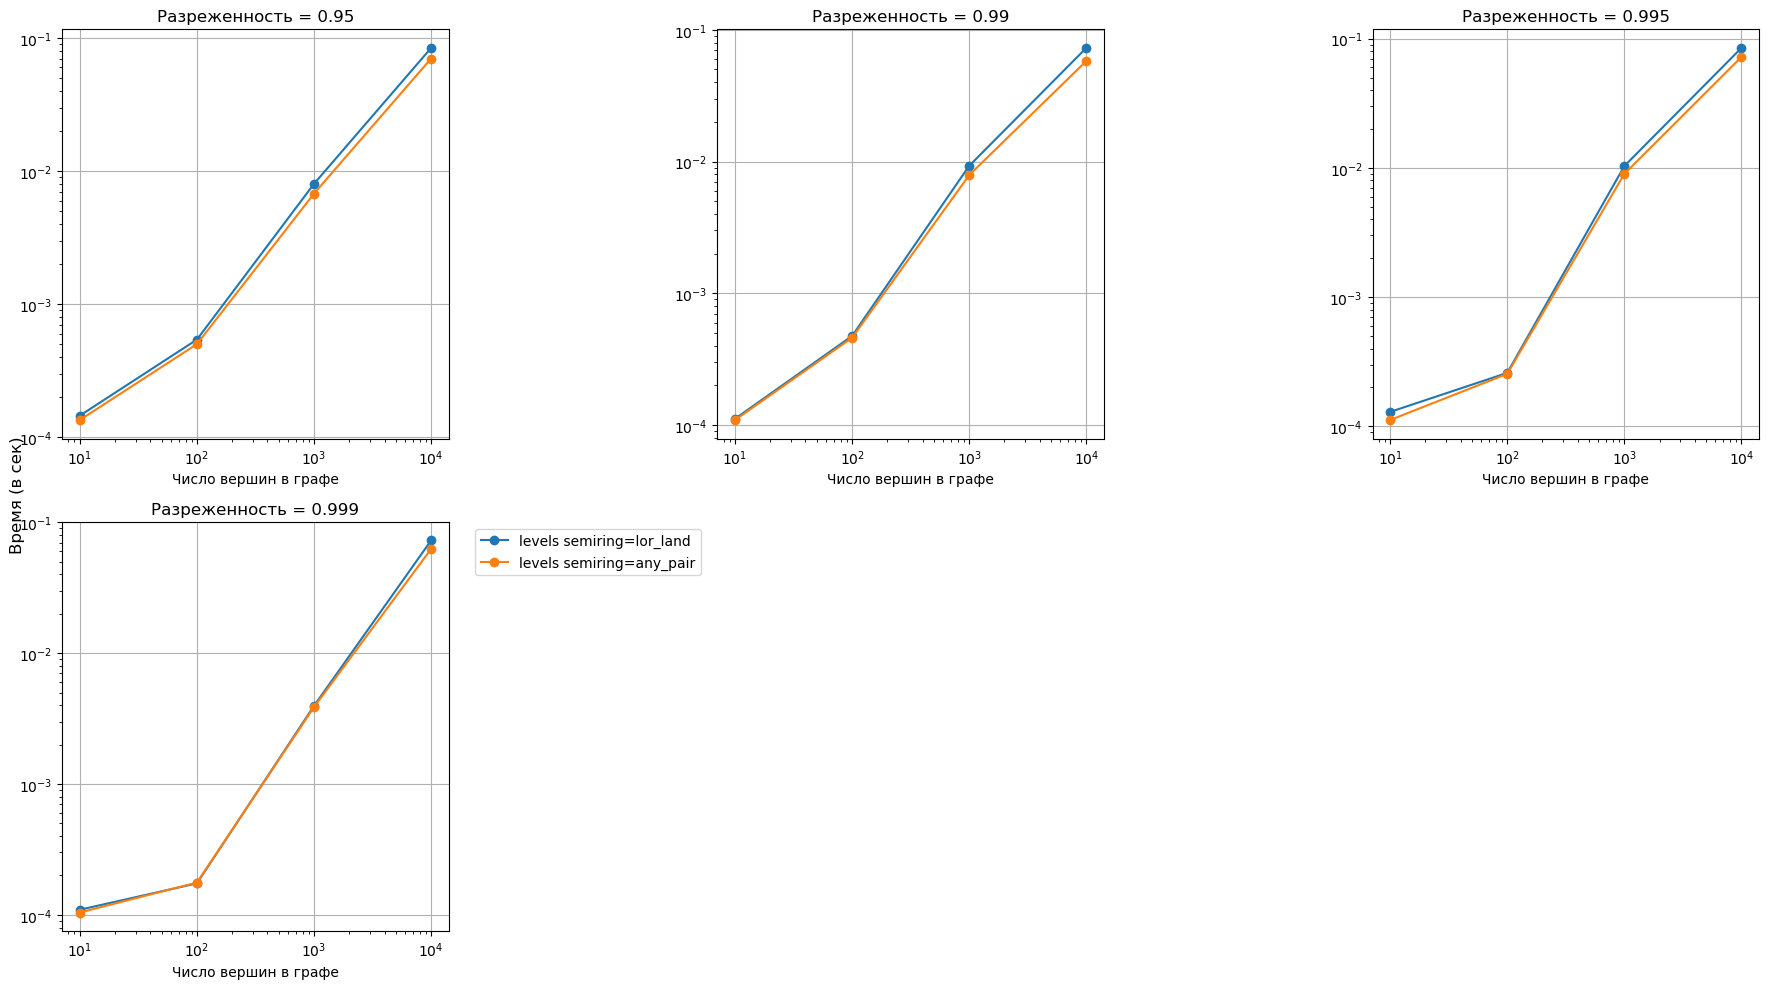

In [89]:
plot_time_vs_param(
    df=results_comparison_df,
    group_cols=["Кол-во строк в матрице смежности", "Разреженность"],
    x_level="Кол-во строк в матрице смежности",
    subplot_level="Разреженность",
    algos_cols=["levels semiring=lor_land", "levels semiring=any_pair"],
    xlabel="Число вершин в графе",
    title_prefix="Разреженность"
)

Полукольца lor_land и any_pair для алгоритма msbfs_levels показывают практически одинаковое время работы при всех размерах графов и уровнях разреженности, но все же для больших графов наблюдается преимущество в скорости у алгоритма, использующего semiring.lor_land.